In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
# Rows are grouped by V_B (top→bottom: small, comparable, large relative to V_C);
# within each row, column 1 = n=2 ($\rho^{(2)}$), column 2 = n=1 ($\rho$).
param_grid = [
    [(2, 2, 2), (2, 2, 1)],
    [(2, 5, 2), (2, 5, 1)],
    [(2, 8, 2), (2, 8, 1)],
]

# Relation between V_B and V_C (V_C = V_total - V_A - V_B), keyed by V_B.
REL_LABELS = {
    2: r"V_B \ll V_C",
    5: r"V_B \approx V_C",
    8: r"V_B \gg V_C",
}

PANEL_LETTERS = [["a", "b"], ["c", "d"], ["e", "f"]]

# ── Font sizes ─
TITLE_FONTSIZE  = 13
LABEL_FONTSIZE  = 13
TICK_FONTSIZE   = 10
CBAR_FONTSIZE   = 10


Saved  fig_9.pdf


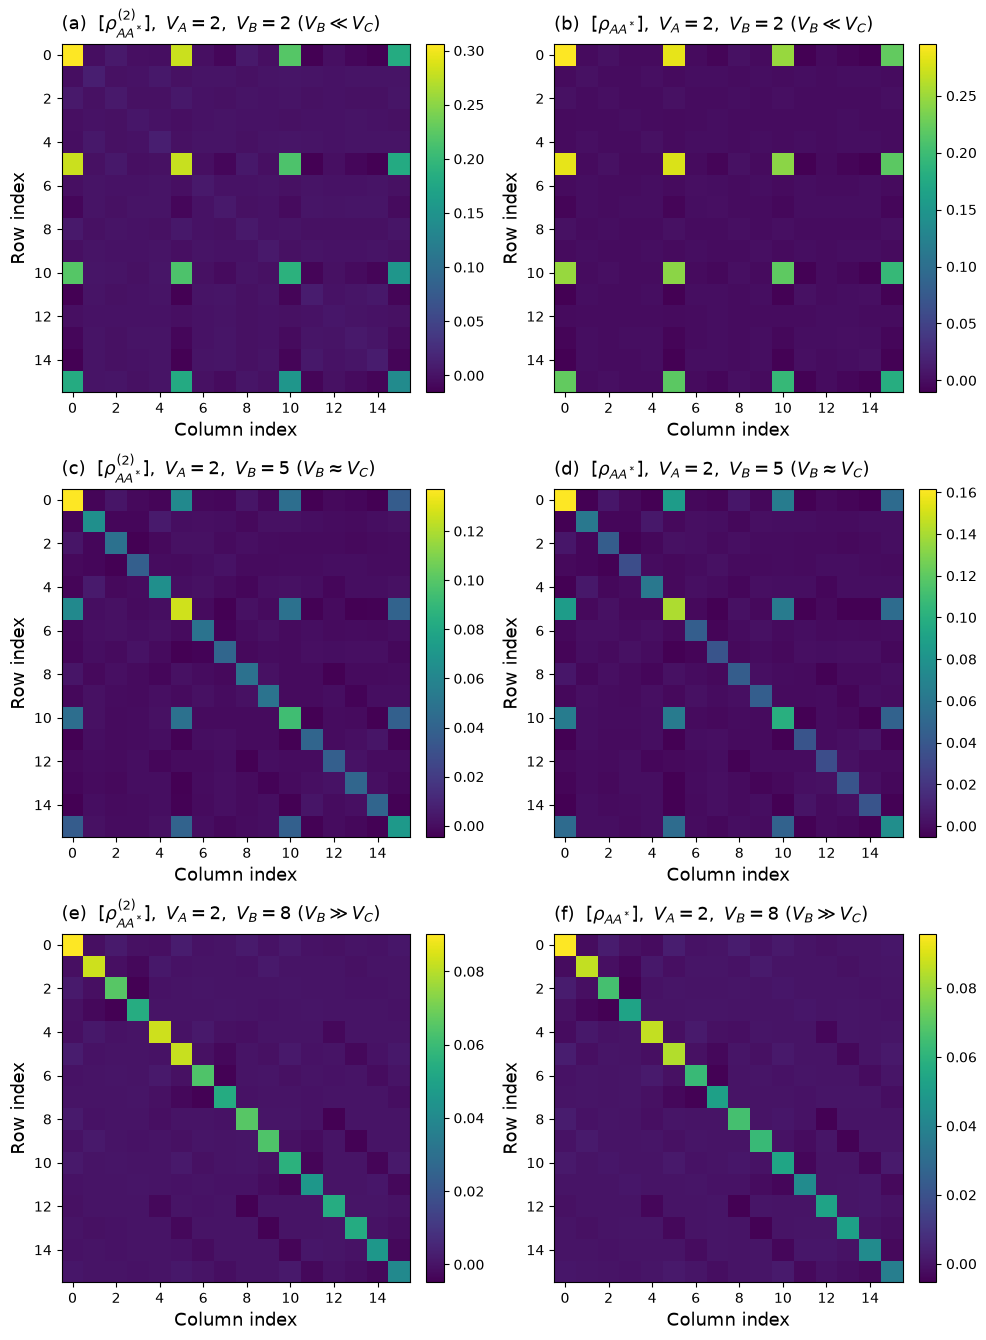

In [3]:
BASE_DIR = Path(".")

fig, axes = plt.subplots(3, 2, figsize=(10, 13.5))

for row_idx, row in enumerate(param_grid):
    for col_idx, (N_A, N_B, n) in enumerate(row):
        ax = axes[row_idx][col_idx]
        letter = PANEL_LETTERS[row_idx][col_idx]

        # Load
        input_filename = BASE_DIR / "matrix_value" / f"rho_AA_avg_VA_{N_A}_VB_{N_B}_n_{n}.csv"
        rho_AA_avg = np.loadtxt(input_filename, delimiter=",")

        # Plot
        im = ax.imshow(rho_AA_avg, aspect="equal", interpolation="nearest", cmap="viridis")

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=CBAR_FONTSIZE)

        ax.set_xlabel("Column index", fontsize=LABEL_FONTSIZE)
        ax.set_ylabel("Row index", fontsize=LABEL_FONTSIZE)

        rho_sym = r"\rho_{AA^*}^{(2)}" if n == 2 else r"\rho_{AA^*}"
        rel = REL_LABELS[N_B]
        ax.set_title(
            rf"({letter})  $[{rho_sym}],\ V_A={N_A},\ V_B={N_B}\ ({rel})$",
            fontsize=TITLE_FONTSIZE,
            loc="left",
            pad=10,
        )

        ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

fig.tight_layout()

output_filename = "fig_9.pdf"
fig.savefig(output_filename, dpi=300, bbox_inches="tight")
print(f"Saved  {output_filename}")

plt.show()
